In [117]:
# Import des données traitées
from numpy import select
import pandas as pd
import duckdb
pd.set_option('display.max_columns', None)

chemin_fichier_order = r"F_orders.parquet"
chemin_fichier_product = r"D_products.parquet"
chemin_fichier_canal = r"d_facture_clean.parquet"
chemin_fichier_client = r"dim_client.parquet"

df_ML_customer=duckdb.query(f"""
    with order_complete as(
        SELECT
            o.*,
            CASE
                WHEN o.TotalDiscountGBP=0 THEN 0
                ELSE 1
            END AS check_promotion,

            --CASE
            --    WHEN o.PromotionCode_clean='NONE' THEN 1
            --    ELSE 0
            --END AS check_promotion_none,
            --CASE
            --    WHEN o.PromotionCode_clean='CLEARANCE' THEN 1
            --    ELSE 0
            --END AS check_promotion_clearance,
            --CASE
            --    WHEN o.PromotionCode_clean='SPRING' THEN 1
            --    ELSE 0
            --END AS check_promotion_spring,
            --CASE
            --    WHEN o.PromotionCode_clean='WELCOME10' THEN 1
            --   ELSE 0
            --END AS check_promotion_welcome,
            --CASE
            --    WHEN o.PromotionCode_clean='XMAS' THEN 1
            --    ELSE 0
            --END AS check_promotion_xmas,
            --CASE
            --    WHEN o.PromotionCode_clean='VIP' THEN 1
            --    ELSE 0
            --END AS check_promotion_vip,

            p.ProductCategory_Propre,
            c.SalesChannel,
            cl.CustomerSegment,
        From read_parquet('{chemin_fichier_order}') as o
        LEFT JOIN read_parquet('{chemin_fichier_product}') as p
            ON p.StockCode = o.StockCode
        LEFT JOIN read_parquet('{chemin_fichier_canal}') as c
            ON c.Invoice=o.Invoice
        LEFT JOIN read_parquet('{chemin_fichier_client}') as cl
            ON cl.CustomerID=o.CustomerID_clean
    )                        

    select 
        CustomerID_clean,
        CustomerSegment,
        COUNT(DISTINCT(OrderLineID)) as total_lignes_commandes,
        SUM(TotalPriceGBP) as total_CA,
        SUM(TotalPriceGBP_WithDiscount) as total_CA_apres_remise,
        SUM(Quantity_clean) as Total_quantite,
        SUM(Quantity_clean)/COUNT(DISTINCT(Invoice)) as quantite_moyenne_par_facture,
        SUM(TotalPriceGBP_WithDiscount)/SUM(Quantity_clean) as panier_moyen,
        SUM(TotalDiscountGBP)/SUM(TotalPriceGBP) as remise_moyenne,
        SUM(check_promotion) as nb_lignecommande_avec_promo,

        --SUM(check_promotion_none) as nb_lignecommande_promo_none,
        --SUM(check_promotion_clearance) as nb_lignecommande_promo_clearance,
        --SUM(check_promotion_spring) as nb_lignecommande_promo_spring,
        --SUM(check_promotion_welcome) as nb_lignecommande_avec_welcome,
        --SUM(check_promotion_xmas) as nb_lignecommande_avec_xmas,
        --SUM(check_promotion_vip) as nb_lignecommande_avec_vip,

        SUM(check_promotion)/COUNT(DISTINCT(OrderLineID))*100 as pourcent_lignescommandes_avec_promo,
        MODE(country_clean) AS pays_prefere,
        MODE(ProductCategory_Propre) AS categorie_preferee,
        MODE(SalesChannel) AS canal_prefere,
        MODE(PromotionCode_clean) AS codePromotion_prefere,
        -- 1. LA RÉCENCE (en jours)
        -- On calcule la différence entre la date d'achat la plus récente (MAX) et notre date de référence
        DATE_DIFF('day', MAX(InvoiceDate_clean), CAST('2012-01-01' AS DATE)) AS recence_jours,
        -- 2. LA FRÉQUENCE SUR 1 AN (Nombre de factures distinctes)
        -- On compte les 'Invoice' uniques, mais UNIQUEMENT si l'achat a eu lieu dans les 365 jours avant la référence
        COUNT(DISTINCT Invoice) FILTER (WHERE DATE_DIFF('day', InvoiceDate_clean, CAST('2012-01-01' AS DATE)) <= 365) AS nb_achats_annee
    From order_complete
    GROUP BY CustomerID_clean, CustomerSegment
""").df()

In [6]:
def explorer_dataset(dataset):
        print(f"Start {'-'*10} Pour ce dataset, la taille est de {dataset.shape} {'-'*10}")
        print('-'*30)
        display(dataset.head(3))
        print('-'*30)
        display(dataset.tail(3))
        print('-'*30)
        print(f"Présences de valeurs 'NaN'.")
        print(f"{dataset.isna().sum()}")
        display(dataset[dataset.isna().any(axis=1)])
        print('-'*30)
        print(f"Les doublons")
        print(f"{dataset.duplicated().sum()}")
        print('-'*30)
        print(f"Les types de données")
        print(f"{dataset.dtypes}")
        print('-'*30)
        print(f"Description")
        display(dataset.describe().T)
        print("FIN"+'-'*100)

In [118]:
explorer_dataset(df_ML_customer)

Start ---------- Pour ce dataset, la taille est de (5943, 17) ----------
------------------------------


,CustomerID_clean,CustomerSegment,total_lignes_commandes,total_CA,total_CA_apres_remise,Total_quantite,quantite_moyenne_par_facture,panier_moyen,remise_moyenne,nb_lignecommande_avec_promo,pourcent_lignescommandes_avec_promo,pays_prefere,categorie_preferee,canal_prefere,codePromotion_prefere,recence_jours,nb_achats_annee
0,18259,Loyal,91,17076.799919,15130.232864,1382.0,197.428571,10.948070,0.113989,81.0,89.010989,United Kingdom,other,Phone,XMAS,47,2
1,15955,Low value,365,53955.680027,48431.276039,4208.0,168.320000,11.509334,0.102388,320.0,87.671233,United Kingdom,other,Store,SPRING,47,15
2,16717,Low value,404,44247.279803,40593.293102,3509.0,175.450000,11.568337,0.082581,300.0,74.257426,United Kingdom,other,Online,WELCOME10,32,8


------------------------------


,CustomerID_clean,CustomerSegment,total_lignes_commandes,total_CA,total_CA_apres_remise,Total_quantite,quantite_moyenne_par_facture,panier_moyen,remise_moyenne,nb_lignecommande_avec_promo,pourcent_lignescommandes_avec_promo,pays_prefere,categorie_preferee,canal_prefere,codePromotion_prefere,recence_jours,nb_achats_annee
5940,17641,VIP,1,17.82,15.147,1.0,1.0,15.147,0.15,1.0,100.0,United Kingdom,seasonal,Store,XMAS,761,0
5941,16291,VIP,1,8.18,8.180,1.0,1.0,8.180,0.00,0.0,0.0,Portugal,other,Phone,NONE,705,0
5942,12382,Loyal,1,8.18,8.180,1.0,1.0,8.180,0.00,0.0,0.0,Netherlands,other,Store,NONE,705,0


------------------------------
Présences de valeurs 'NaN'.
CustomerID_clean                       0
CustomerSegment                        0
total_lignes_commandes                 0
total_CA                               0
total_CA_apres_remise                  0
Total_quantite                         0
quantite_moyenne_par_facture           0
panier_moyen                           0
remise_moyenne                         0
nb_lignecommande_avec_promo            0
pourcent_lignescommandes_avec_promo    0
pays_prefere                           0
categorie_preferee                     0
canal_prefere                          0
codePromotion_prefere                  0
recence_jours                          0
nb_achats_annee                        0
dtype: int64


,CustomerID_clean,CustomerSegment,total_lignes_commandes,total_CA,total_CA_apres_remise,Total_quantite,quantite_moyenne_par_facture,panier_moyen,remise_moyenne,nb_lignecommande_avec_promo,pourcent_lignescommandes_avec_promo,pays_prefere,categorie_preferee,canal_prefere,codePromotion_prefere,recence_jours,nb_achats_annee


------------------------------
Les doublons
0
------------------------------
Les types de données
CustomerID_clean                           str
CustomerSegment                            str
total_lignes_commandes                   int64
total_CA                               float64
total_CA_apres_remise                  float64
Total_quantite                         float64
quantite_moyenne_par_facture           float64
panier_moyen                           float64
remise_moyenne                         float64
nb_lignecommande_avec_promo            float64
pourcent_lignescommandes_avec_promo    float64
pays_prefere                               str
categorie_preferee                         str
canal_prefere                              str
codePromotion_prefere                      str
recence_jours                            int64
nb_achats_annee                          int64
dtype: object
------------------------------
Description


,count,mean,std,min,25%,50%,75%,max
total_lignes_commandes,5943.0,179.601380,3298.938358,1.00,20.000000,53.000000,142.000000,2.529750e+05
total_CA,5943.0,24775.860975,258726.484456,1.01,2150.509975,5755.819992,16461.415150,1.822348e+07
total_CA_apres_remise,5943.0,22334.985811,234410.711011,1.01,1934.555722,5174.557998,14837.703384,1.651994e+07
Total_quantite,5943.0,2089.351338,23421.199661,1.00,184.000000,483.000000,1370.000000,1.670108e+06
quantite_moyenne_par_facture,5943.0,213.541862,1303.555676,1.00,79.000000,134.000000,221.125000,8.716700e+04
panier_moyen,5943.0,11.031162,2.845721,1.01,9.379558,10.795079,12.328893,3.237600e+01
remise_moyenne,5943.0,0.100254,0.050353,0.00,0.066447,0.100000,0.133333,2.045659e-01
nb_lignecommande_avec_promo,5943.0,143.660946,2632.461554,0.00,15.000000,42.000000,116.000000,2.018610e+05
pourcent_lignescommandes_avec_promo,5943.0,80.206415,27.768302,0.00,70.000000,93.333333,100.000000,1.000000e+02
recence_jours,5943.0,225.457681,211.882061,23.00,47.000000,118.000000,404.000000,7.610000e+02


FIN----------------------------------------------------------------------------------------------------


In [119]:
df_ML_customer.sample(10)

,CustomerID_clean,CustomerSegment,total_lignes_commandes,total_CA,total_CA_apres_remise,Total_quantite,quantite_moyenne_par_facture,panier_moyen,remise_moyenne,nb_lignecommande_avec_promo,pourcent_lignescommandes_avec_promo,pays_prefere,categorie_preferee,canal_prefere,codePromotion_prefere,recence_jours,nb_achats_annee
2398,15456,Loyal,227,26397.139744,24736.182685,2785.0,278.500000,8.881933,0.062922,184.0,81.057269,United Kingdom,home decoration,Online,SPRING,306,2
4071,13905,Low value,15,2267.329989,2151.557478,146.0,48.666667,14.736695,0.051061,15.0,100.000000,United Kingdom,home decoration,Online,SPRING,594,0
831,17381,Regular,171,460964.249828,423716.513876,43666.0,1149.105263,9.703580,0.080804,149.0,87.134503,United Kingdom,other,Online,SPRING,31,27
1820,17401,Loyal,12,537.670004,430.136012,34.0,34.000000,12.651059,0.200000,12.0,100.000000,United Kingdom,kitchenware,Online,CLEARANCE,564,0
762,17707,Regular,24,11292.549690,10156.571384,535.0,59.444444,18.984246,0.100595,22.0,91.666667,United Kingdom,kitchenware,Marketplace,WELCOME10,208,2
3419,17243,Low value,1142,106002.839972,95998.539403,8168.0,102.100000,11.753004,0.094378,871.0,76.269702,United Kingdom,other,Phone,NONE,24,27
3523,12472,Loyal,1041,123999.559904,113016.105321,11687.0,315.864865,9.670241,0.088577,705.0,67.723343,Germany,other,Store,XMAS,53,11
4396,16482,Regular,17,4669.139999,4669.139999,334.0,334.000000,13.979461,0.000000,0.0,0.000000,United Kingdom,other,Phone,NONE,38,1
5825,13706,Loyal,38,2681.180026,2510.583977,301.0,150.500000,8.340811,0.063627,38.0,100.000000,United Kingdom,other,Marketplace,SPRING,325,1
5773,16704,Low value,57,4484.890020,3990.542964,454.0,227.000000,8.789742,0.110225,57.0,100.000000,United Kingdom,other,Online,WELCOME10,641,0


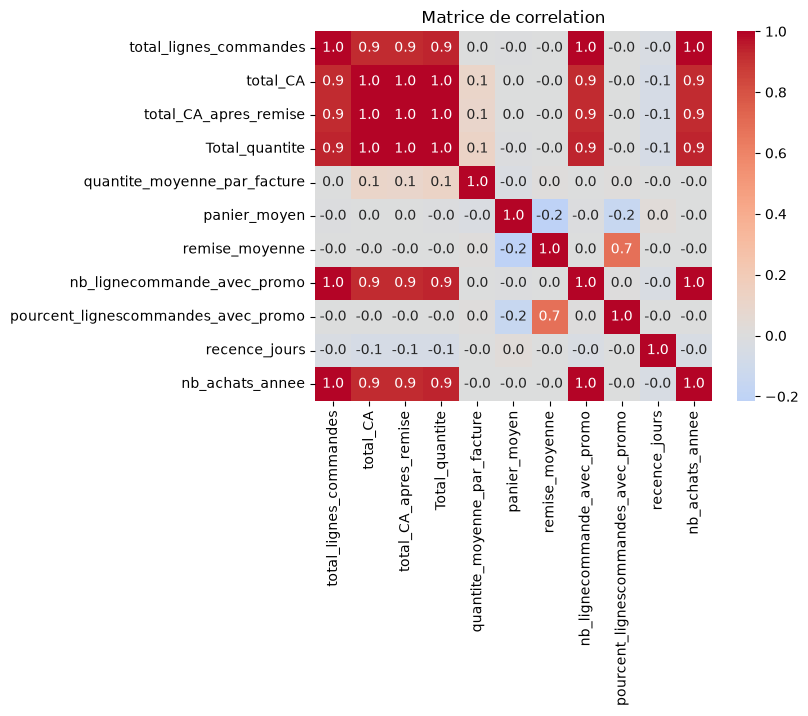

In [120]:
import seaborn as sns
import matplotlib.pyplot as plt

correlation=df_ML_customer.select_dtypes(include='number').corr()

sns.heatmap(correlation, annot=True, fmt='.1f', cmap='coolwarm', center=0)
plt.title("Matrice de correlation")
plt.show()

In [121]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import (
    silhouette_score,
    confusion_matrix
)
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

In [151]:
X=df_ML_customer[['total_CA_apres_remise', 'quantite_moyenne_par_facture', 'panier_moyen','remise_moyenne', 'pourcent_lignescommandes_avec_promo','recence_jours','canal_prefere']]
y_segment= df_ML_customer['CustomerSegment']

num_cols = X.select_dtypes(include="number").columns
cat_cols = X.select_dtypes(exclude="number").columns

# Transformations numériques
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

# Transformations catégoriques
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

# Préprocess : le ColumnTransformer va dire à quelles colonnes appliquer quel transformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_cols),
        ('cat', categorical_transformer, cat_cols)
    ])

# Créer le pipeline complet avec une régression linéaire
pipeline_DBSCAN = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', DBSCAN(eps=1.45,min_samples=3))
])

In [152]:
labels=pipeline_DBSCAN.fit_predict(X)

In [153]:
resultats = X.copy()
resultats["segment"] = labels

resultats.sample(10)

,total_CA_apres_remise,quantite_moyenne_par_facture,panier_moyen,remise_moyenne,pourcent_lignescommandes_avec_promo,recence_jours,canal_prefere,segment
3762,387.268509,55.000000,7.041246,0.150000,100.000000,79,Phone,0
3716,10849.268074,247.000000,10.981041,0.194608,100.000000,289,Store,0
2338,7194.716013,46.363636,14.107286,0.089972,61.538462,55,Phone,0
1645,15381.267060,323.750000,11.877426,0.176845,100.000000,38,Store,0
3824,6009.739481,394.000000,7.626573,0.052516,100.000000,41,Phone,0
252,1177.199973,89.000000,13.226966,0.100000,100.000000,469,Phone,0
4207,4769.227026,134.500000,8.864734,0.070942,80.851064,180,Marketplace,0
3833,8222.794024,69.454545,10.762819,0.120726,100.000000,24,Online,0
622,2862.590053,172.500000,8.297362,0.108030,100.000000,30,Store,0
4514,2320.672046,314.000000,7.390675,0.200000,100.000000,24,Online,0


In [154]:
import pandas as pd

pd.Series(labels).value_counts()

 0    5896
-1      37
 1       6
 2       4
Name: count, dtype: int64

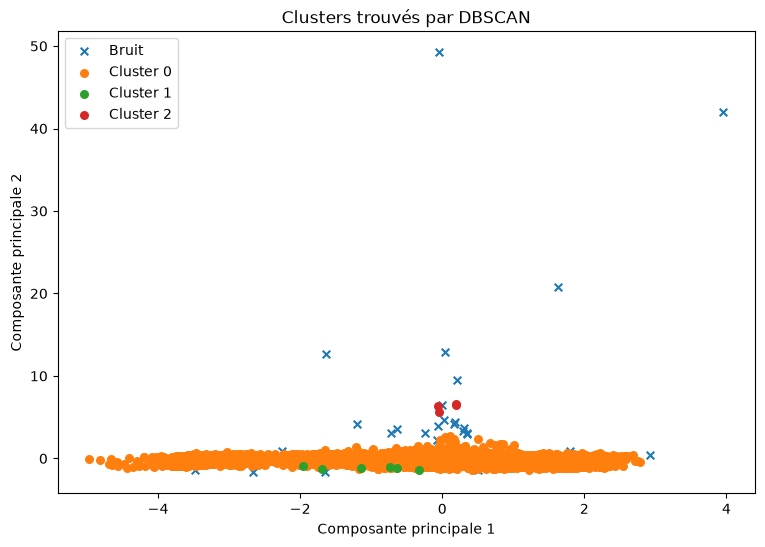

In [156]:
X_preprocessed = preprocessor.fit_transform(X)

# 2. Sécurité : Le OneHotEncoder crée des matrices "creuses" (sparse) pour économiser de la RAM.
# Mais la fonction PCA classique déteste ça. On convertit donc en tableau dense si nécessaire.
if hasattr(X_preprocessed, "toarray"):
    X_preprocessed = X_preprocessed.toarray()

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_preprocessed)

plt.figure(figsize=(9, 6))

for label in np.unique(labels):
    masque = labels == label

    if label == -1:
        nom = "Bruit"
        marker = "x"
    else:
        nom = f"Cluster {label}"
        marker = "o"

    plt.scatter(
        X_pca[masque, 0],
        X_pca[masque, 1],
        label=nom,
        marker=marker,
        s=30
    )

plt.xlabel("Composante principale 1")
plt.ylabel("Composante principale 2")
plt.title("Clusters trouvés par DBSCAN")
plt.legend()

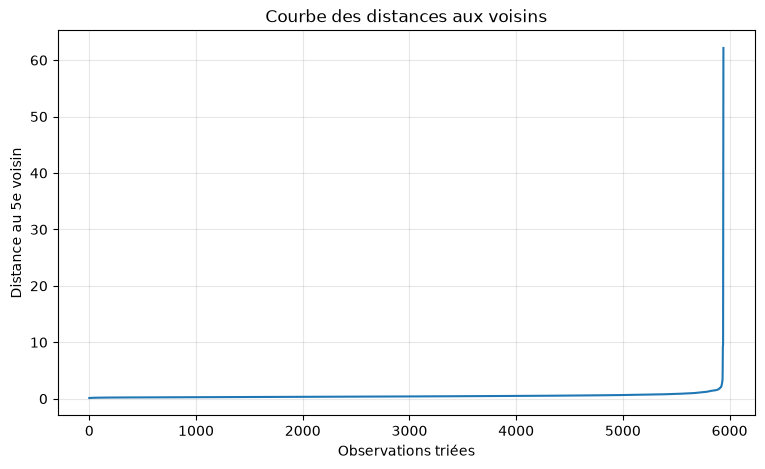

In [142]:
# on va regarder à quelle distance se trouve le 5ème voisin
min_samples = 5

# pour chaque point, on chercher les 5 voisins les plus proches
neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors_fit = neighbors.fit(X_preprocessed)

distances, indices = neighbors_fit.kneighbors(X_preprocessed)

# La dernière colonne contient la distance vers le k-ième voisin.
k_distances = np.sort(distances[:, -1])

plt.figure(figsize=(9, 5))
plt.plot(k_distances)
plt.xlabel("Observations triées")
plt.ylabel(f"Distance au {min_samples}e voisin")
plt.title("Courbe des distances aux voisins")
plt.grid(alpha=0.3)
plt.show()

In [143]:
def evaluer_dbscan(X, eps, min_samples=5):
    modele = DBSCAN(
        eps=eps,
        min_samples=min_samples
    )

    labels = modele.fit_predict(X)

    masque_non_bruit = labels != -1
    labels_non_bruit = labels[masque_non_bruit]

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = np.sum(labels == -1)

    silhouette = np.nan

    if (
        n_clusters >= 2
        and np.sum(masque_non_bruit) > n_clusters
    ):
        silhouette = silhouette_score(
            X[masque_non_bruit],
            labels_non_bruit
        )

    return {
        "eps": eps,
        "min_samples": min_samples,
        "nb_clusters": n_clusters,
        "nb_bruit": n_noise,
        "part_bruit": n_noise / len(X),
        "silhouette_sans_bruit": silhouette
    }


In [144]:
eps_values = np.arange(1.4,1.5, 0.01)

comparaison_eps = pd.DataFrame([
    evaluer_dbscan(
        X_preprocessed,
        eps=round(eps, 2),
        min_samples=5
    )
    for eps in eps_values
])

comparaison_eps

,eps,min_samples,nb_clusters,nb_bruit,part_bruit,silhouette_sans_bruit
0,1.40,5,6,52,0.008750,0.137424
1,1.41,5,6,49,0.008245,0.137163
2,1.42,5,3,48,0.008077,0.416523
3,1.43,5,3,47,0.007908,0.416278
4,1.44,5,2,47,0.007908,0.493968
5,1.45,5,2,44,0.007404,0.493628
6,1.46,5,2,44,0.007404,0.493628
7,1.47,5,2,42,0.007067,0.493392
8,1.48,5,2,41,0.006899,0.493329
9,1.49,5,2,41,0.006899,0.493329


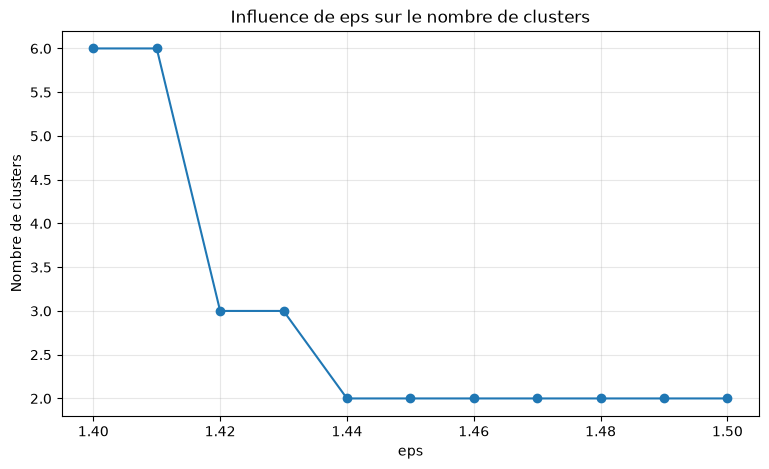

In [145]:
plt.figure(figsize=(9, 5))
plt.plot(
    comparaison_eps["eps"],
    comparaison_eps["nb_clusters"],
    marker="o"
)
plt.xlabel("eps")
plt.ylabel("Nombre de clusters")
plt.title("Influence de eps sur le nombre de clusters")
plt.grid(alpha=0.3)
plt.show()

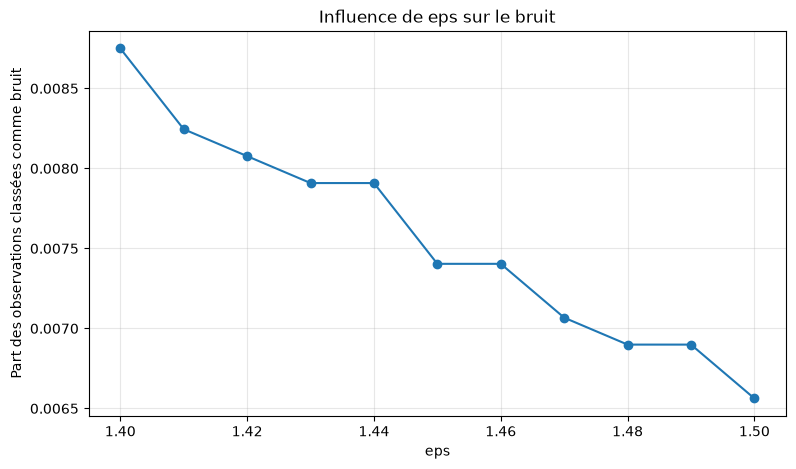

In [146]:
plt.figure(figsize=(9, 5))
plt.plot(
    comparaison_eps["eps"],
    comparaison_eps["part_bruit"],
    marker="o"
)
plt.xlabel("eps")
plt.ylabel("Part des observations classées comme bruit")
plt.title("Influence de eps sur le bruit")
plt.grid(alpha=0.3)
plt.show()

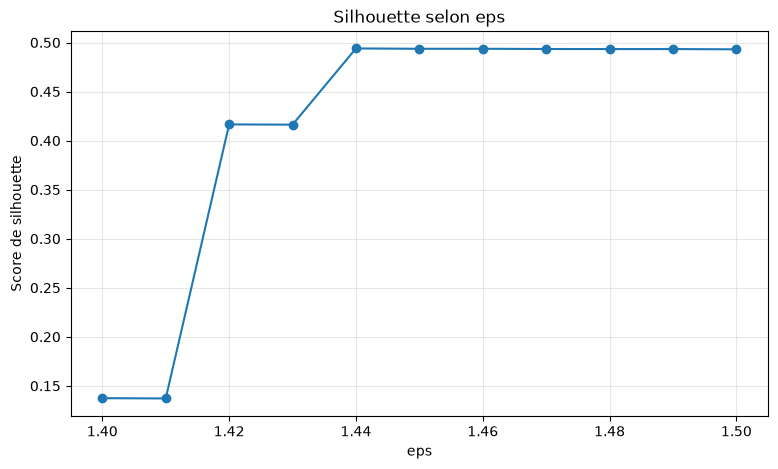

In [147]:
plt.figure(figsize=(9, 5))
plt.plot(
    comparaison_eps["eps"],
    comparaison_eps["silhouette_sans_bruit"],
    marker="o"
)
plt.xlabel("eps")
plt.ylabel("Score de silhouette")
plt.title("Silhouette selon eps")
plt.grid(alpha=0.3)
plt.show()

In [148]:
resultats_parametres = []

for min_samples in [3, 4, 5, 6, 8, 10]:
    for eps in np.arange(1.45, 1.48, 0.005):
        resultats_parametres.append(
            evaluer_dbscan(
                X_preprocessed,
                eps=round(eps, 2),
                min_samples=min_samples
            )
        )

comparaison_parametres = pd.DataFrame(resultats_parametres)

comparaison_parametres.sort_values(
    by=["silhouette_sans_bruit", "part_bruit"],
    ascending=[False, True]
).head(20)


,eps,min_samples,nb_clusters,nb_bruit,part_bruit,silhouette_sans_bruit
7,1.45,4,2,43,0.007235,0.501495
8,1.45,4,2,43,0.007235,0.501495
9,1.46,4,2,43,0.007235,0.501495
10,1.46,4,2,43,0.007235,0.501495
0,1.45,3,3,37,0.006226,0.501317
1,1.45,3,3,37,0.006226,0.501317
2,1.46,3,3,37,0.006226,0.501317
3,1.46,3,3,37,0.006226,0.501317
11,1.47,4,2,39,0.006562,0.501148
12,1.47,4,2,39,0.006562,0.501148


In [149]:
dbscan_final = DBSCAN(
    eps=1.47,
    min_samples=3
)

labels_final = dbscan_final.fit_predict(X_preprocessed)

n_clusters_final = len(set(labels_final)) - (1 if -1 in labels_final else 0)
n_noise_final = np.sum(labels_final == -1)

print("Nombre de clusters :", n_clusters_final)
print("Nombre de points de bruit :", n_noise_final)
print("Labels présents :", np.unique(labels_final))

Nombre de clusters : 3
Nombre de points de bruit : 33
Labels présents : [-1  0  1  2]


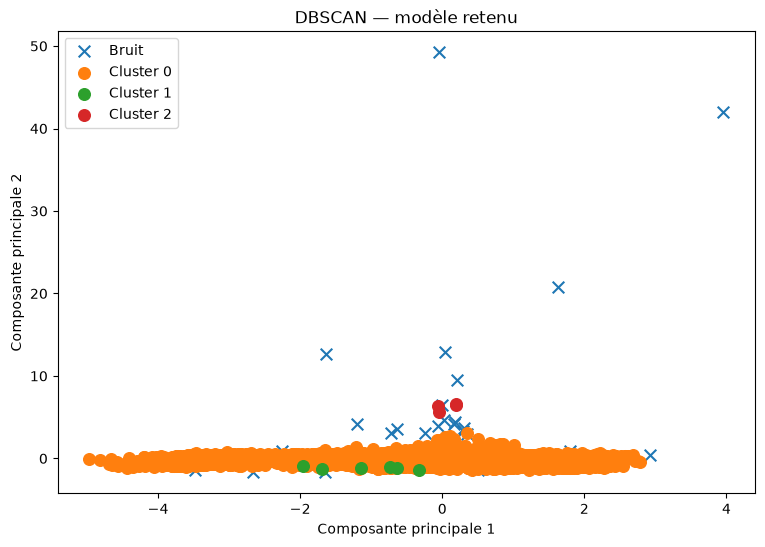

In [150]:
plt.figure(figsize=(9, 6))

for label in np.unique(labels_final):
    masque = labels_final == label

    if label == -1:
        nom = "Bruit"
        marker = "x"
    else:
        nom = f"Cluster {label}"
        marker = "o"

    plt.scatter(
        X_pca[masque, 0],
        X_pca[masque, 1],
        label=nom,
        marker=marker,
        s=70
    )

plt.xlabel("Composante principale 1")
plt.ylabel("Composante principale 2")
plt.title("DBSCAN — modèle retenu")
plt.legend()
plt.show()
